In [5]:
import numpy as np # Import the NumPy library for numerical operations, aliased as np
import pandas as pd # Import the Pandas library for data manipulation and analysis, aliased as pd
import matplotlib.pyplot as plt # Import the Matplotlib library for plotting, specifically the pyplot module, aliased as plt

# Import various modules from scikit-learn for machine learning tasks
from sklearn.linear_model import LinearRegression, Ridge, Lasso # Linear models: standard, Ridge (L2 regularization), Lasso (L1 regularization)
from sklearn.model_selection import train_test_split, KFold, cross_validate, validation_curve # Model selection tools: data splitting, cross-validation, and validation curve
from sklearn.metrics import mean_squared_error, r2_score # Metrics for evaluating model performance: Mean Squared Error and R-squared
from sklearn.pipeline import Pipeline # Tool for chaining multiple processing steps
from sklearn.preprocessing import PolynomialFeatures, StandardScaler # Preprocessing tools: polynomial feature creation, feature scaling

RANDOM_STATE = 42 # Define a fixed random state for reproducibility of results
rng = np.random.default_rng(RANDOM_STATE) # Initialize a default random number generator with the fixed state

# Configure Matplotlib default plot parameters for consistent styling
plt.rcParams.update({ # Update Matplotlib's default runtime configuration parameters
    "figure.figsize": (9, 5), # Set default figure size for plots to 9 inches width, 5 inches height
    "axes.grid": True, # Enable grid lines on axes by default
    "grid.alpha": 0.25, # Set the transparency (alpha) of the grid lines to 25%
    "axes.spines.top": False, # Hide the top spine (border) of the axes
    "axes.spines.right": False, # Hide the right spine (border) of the axes
    "font.size": 11, # Set the default font size for text elements in plots to 11
})

print("Libraries loaded successfully.") # Print a confirmation message once libraries are loaded

Libraries loaded successfully.


In [14]:
X_simple = np.linspace(-3, 3, 50).reshape(-1, 1) # Generate 50 evenly spaced points between -3 and 3 for X, reshape to a column vector --it'll be 50 cross 1 vector.
y_simple = X_simple ** 2 + np.random.normal(0, 1, X_simple.shape[0]).reshape(-1, 1) # ground truth - Generate y values based on X_simple squared, with added Gaussian noise, reshape to a column vector

# print (X_simple)
# print (y_simple)

**PolynomialFeatures**

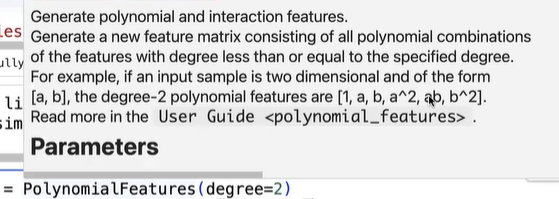


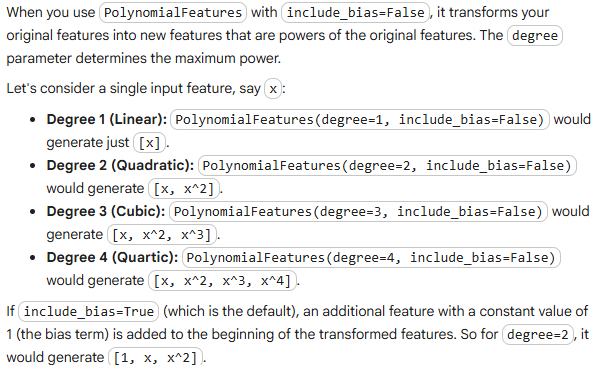

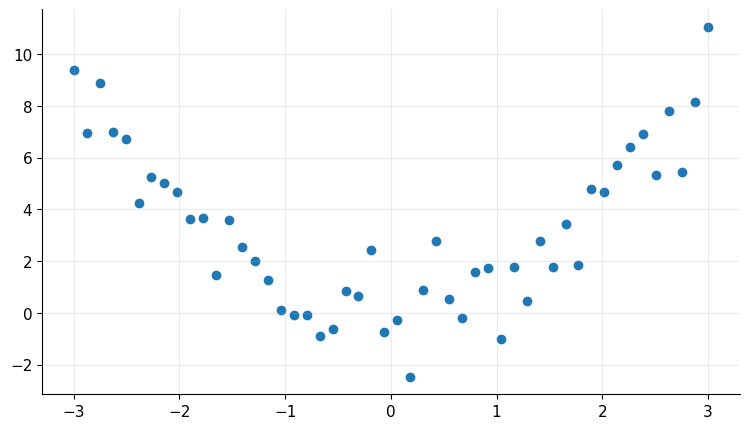

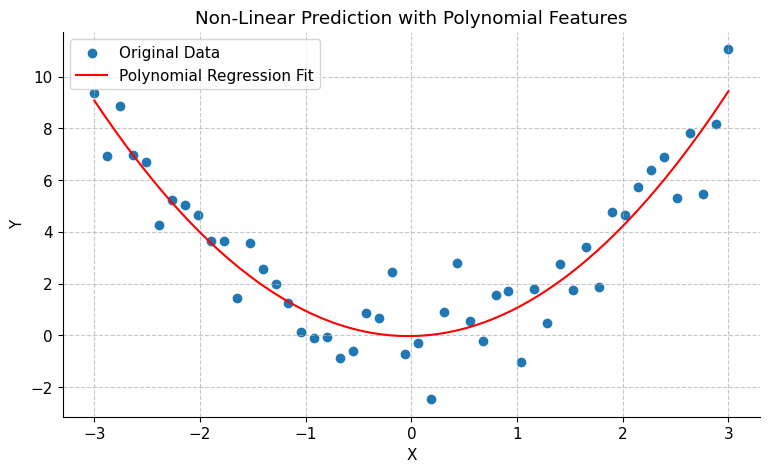

In [16]:
poly_features = PolynomialFeatures(degree=2) # Create a PolynomialFeatures object to transform features up to degree 2
# PolynomialFeatures livrary from scikitlearn - used to generate polynomial and interaction features / transforms the existing features ploynomial

X_poly = poly_features.fit_transform(X_simple) # Fit and transform X_simple to include polynomial features
#print(X_poly)  # since we are transforming the input as degree 2 feautures , we are considering actual value (1),a , a*2
plt.scatter(X_simple, y_simple) # Plot the original X_simple and y_simple data points as a scatter plot
plt.show() # Display the scatter plot

model_simple = LinearRegression() # Initialize a standard Linear Regression model
model_simple.fit(X_poly, y_simple) # Train the model using the polynomial features of X_simple and y_simple
# NOTE: So we are basically iniatiating a linear regresion model only BUT we are fitting it on ENGINEERED dataset (generated by polynomialFeautures object)

# Generate predictions for plotting over a continuous range
x_grid_simple = np.linspace(-3, 3, 200).reshape(-1, 1) # Create a denser grid of X values (200 points) for smooth plotting, reshape to a column vector
# Transform the grid points into polynomial features using the same PolynomialFeatures object
x_grid_poly_simple = poly_features.transform(x_grid_simple) # Transform the dense X grid into polynomial features using the previously fitted 'poly_features' transformer
y_pred_simple = model_simple.predict(x_grid_poly_simple) # Predict y values using the trained model and the polynomial features of the dense X grid


# Plot the original data and the polynomial regression fit
plt.figure(figsize=(9, 5)) # Create a new figure for the plot with a specified size
plt.scatter(X_simple, y_simple, label='Original Data') # Plot the original data points as a scatter plot with a label
plt.plot(x_grid_simple, y_pred_simple, color='red', label='Polynomial Regression Fit') # Plot the polynomial regression curve using the predictions, in red, with a label
plt.title('Non-Linear Prediction with Polynomial Features') # Set the title of the plot
plt.xlabel('X') # Set the label for the x-axis
plt.ylabel('Y') # Set the label for the y-axis
plt.legend() # Display the legend to identify the plotted elements
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid to the plot for readability, with a dashed linestyle and 70% transparency
plt.show() # Display the plot

In [18]:
def true_curve(x): # Define a function to represent the true underlying non-linear curve
    return 2.5 + 1.4*x - 0.35 * x ** 2 + 0.04 * x ** 3 # Returns a cubic polynomial calculation

def make_curve_data(n=45, noise=3.0, x_min=-5, x_max=8, seed=42): # Function to generate synthetic data with a curved relationship
    local_rng = np.random.default_rng(seed) # Initialize a local random number generator for reproducibility with a given seed
    x = np.sort(local_rng.uniform(x_min, x_max, n)) # Generate 'n' sorted x values uniformly within the specified range [x_min, x_max]
    y_true = true_curve(x) # Calculate the true y values based on the 'true_curve' function and the generated x values
    y = y_true + local_rng.normal(0, noise, n) # Add Gaussian (normal distributed) noise to the true y values to simulate observed data
    return x.reshape(-1, 1), y, y_true # Return x (reshaped to a column vector), noisy y, and the true y values

def rmse(y_true, y_pred): # Define a function to calculate the Root Mean Squared Error (RMSE)
    return np.sqrt(mean_squared_error(y_true, y_pred)) # Calculate and return the square root of the mean squared error between true and predicted values

def polynomial_model(degree, regularizer=None, alpha=1.0): # Function to create a scikit-learn pipeline for polynomial regression models
    if regularizer is None: # Check if no regularization is specified
        estimator = LinearRegression() # Use standard Linear Regression as the estimator
        return Pipeline([ # Create a scikit-learn Pipeline object
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)), # Step 1: Create polynomial features up to 'degree', excluding the bias term
            ("scaler", StandardScaler()), # Step 2: Scale the features to have zero mean and unit variance
            ("model", estimator) # Step 3: Apply the linear regression model
        ])
    if regularizer == "ridge": # Check if Ridge regularization is specified
        estimator = Ridge(alpha=alpha) # Initialize Ridge regression with a given 'alpha' (regularization strength)
    elif regularizer == "lasso": # Check if Lasso regularization is specified
        estimator = Lasso(alpha=alpha, max_iter=20000) # Initialize Lasso regression with a given 'alpha' and increased max_iter for convergence
    else: # Handle invalid regularizer types
        raise ValueError("regularizer must be None, 'ridge', or 'lasso'") # Raise an error for an unknown regularizer type
    return Pipeline([ # Create a scikit-learn Pipeline object for regularized models
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)), # Step 1: Create polynomial features up to 'degree', excluding the bias term
        ("scaler", StandardScaler()), # Step 2: Scale the features
        ("model", estimator), # Step 3: Apply the specified regularized linear model (Ridge or Lasso)
    ])

def plot_data_and_true_curve(X, y, title="Noisy curved data"): # Function to plot observed data and the true underlying curve
    x_grid = np.linspace(X.min() - 0.5, X.max() + 0.5, 400).reshape(-1, 1) # Create a dense x-grid for smooth plotting, extending slightly beyond the data range
    plt.figure(figsize=(9, 5)) # Create a new figure for the plot with a specified size
    plt.scatter(X[:, 0], y, color="#18202a", s=45, label="observed noisy data") # Plot the observed noisy data points as a scatter plot
    plt.plot(x_grid[:, 0], true_curve(x_grid[:, 0]), color="#11875d", linewidth=3, label="true underlying curve") # Plot the true underlying curve using the 'true_curve' function
    plt.title(title) # Set the title of the plot
    plt.xlabel("x") # Set the x-axis label
    plt.ylabel("y") # Set the y-axis label
    plt.legend() # Display the legend to identify the plotted elements
    plt.show() # Display the plot

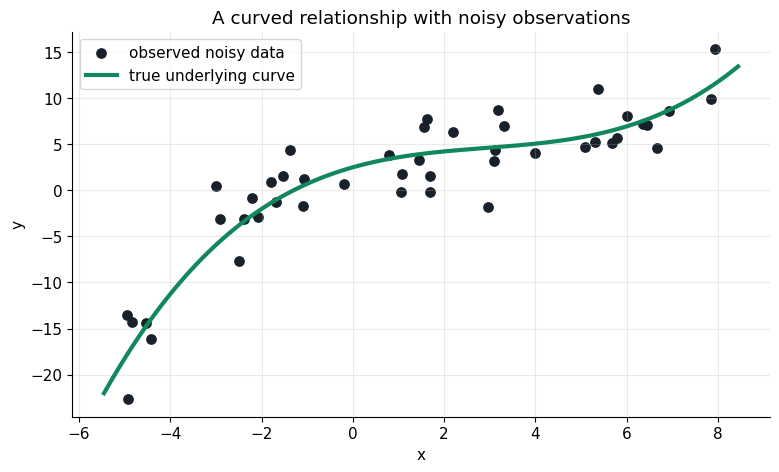

In [19]:
X, y, y_true = make_curve_data(n=45, noise=3.2, seed=7) # Generate synthetic data using the 'make_curve_data' function with specific parameters
plot_data_and_true_curve(X, y, title="A curved relationship with noisy observations") # Plot the generated data and the true curve with a descriptive title

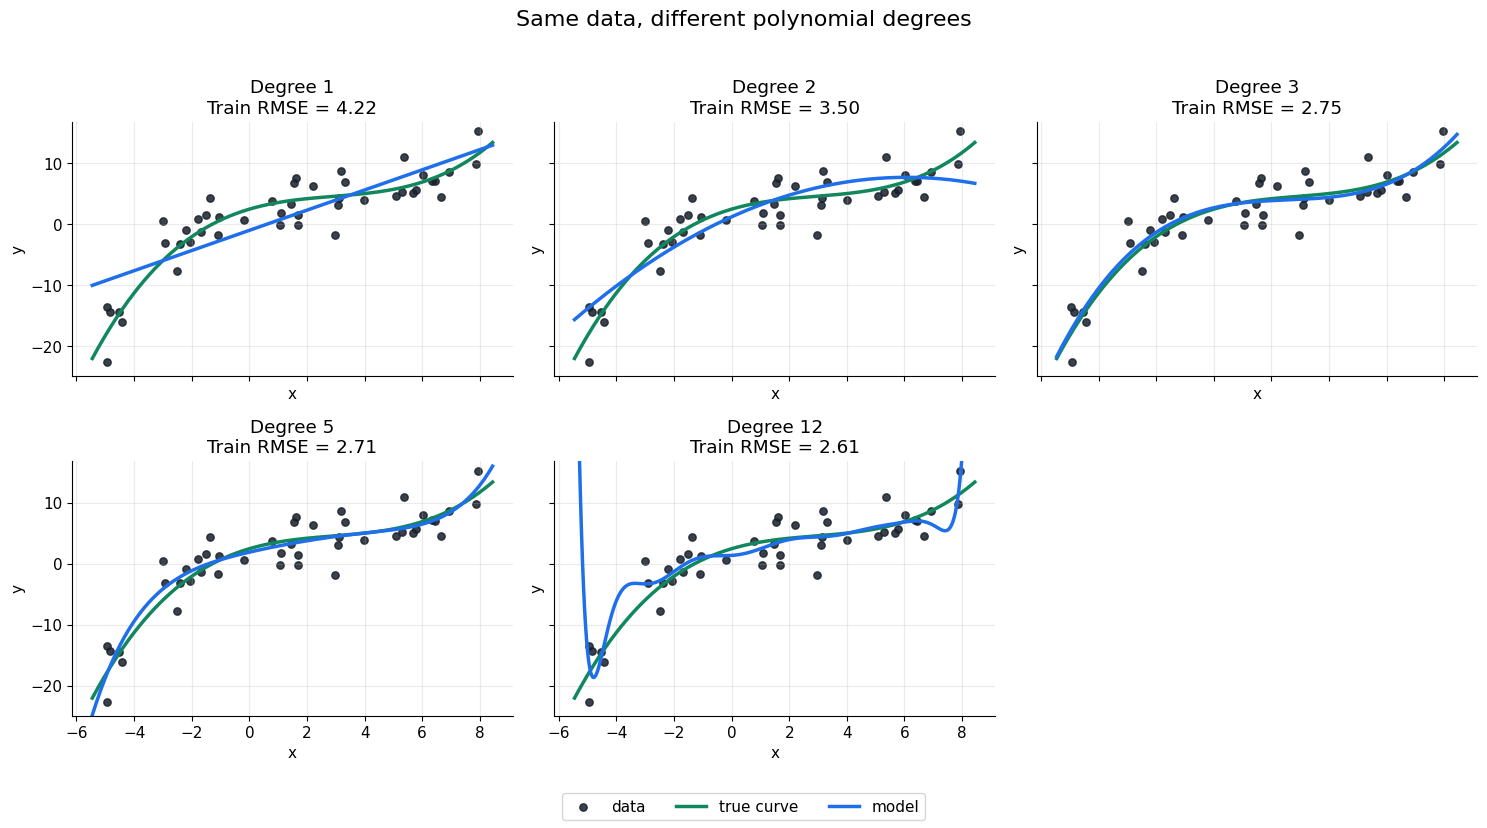

In [20]:
degrees = [1, 2, 3, 5, 12] # Define a list of polynomial degrees to test
x_grid = np.linspace(X.min() - 0.5, X.max() + 0.5, 400).reshape(-1, 1) # Create a dense x-grid for plotting model predictions, extending slightly beyond the data range

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True) # Create a 2x3 grid of subplots, sharing x and y axes for consistent scaling
axes = axes.ravel() # Flatten the 2D array of axes into a 1D array for easier iteration

# Determine appropriate y-limits based on data and true curve to ensure consistent scaling across subplots
y_min_overall = min(y.min(), true_curve(x_grid[:, 0]).min()) * 1.1 # Calculate the overall minimum y-value, adding some padding
y_max_overall = max(y.max(), true_curve(x_grid[:, 0]).max()) * 1.1 # Calculate the overall maximum y-value, adding some padding

for ax, degree in zip(axes, degrees): # Iterate through each subplot axis and corresponding degree from the 'degrees' list
    model = polynomial_model(degree) # Create a polynomial model pipeline for the current 'degree'
    model.fit(X, y) # Train the model on the full dataset X and y

    y_pred_grid = model.predict(x_grid) # Predict y values for the dense x-grid to plot the model's curve
    y_pred_train = model.predict(X) # Predict y values for the original training data X to calculate training error

    ax.scatter(X[:, 0], y, color="#18202a", s=28, alpha=0.85, label="data") # Plot the original data points on the current subplot
    ax.plot(x_grid[:, 0], true_curve(x_grid[:, 0]), color="#11875d", linewidth=2.5, label="true curve") # Plot the true underlying curve
    ax.plot(x_grid[:, 0], y_pred_grid, color="#1f6feb", linewidth=2.5, label="model") # Plot the model's prediction curve
    ax.set_title(f"Degree {degree}\nTrain RMSE = {rmse(y, y_pred_train):.2f}") # Set subplot title with the current degree and the training RMSE (formatted to 2 decimal places)
    ax.set_xlabel("x") # Set x-axis label for the current subplot
    ax.set_ylabel("y") # Set y-axis label for the current subplot
    ax.set_ylim(y_min_overall, y_max_overall) # Apply the consistent y-axis limits determined earlier

axes[-1].axis("off") # Turn off the last unused subplot axis to avoid an empty plot
handles, labels = axes[0].get_legend_handles_labels() # Get legend handles and labels from the first subplot to create a common legend
fig.legend(handles, labels, loc="lower center", ncol=3) # Create a single legend for the entire figure at the bottom center with 3 columns
fig.suptitle("Same data, different polynomial degrees", fontsize=16, y=1.02) # Set a main title for the entire figure, positioned slightly above the subplots
plt.tight_layout(rect=[0, 0.06, 1, 1]) # Adjust subplot parameters for a tight layout, leaving space for the legend and suptitle
plt.show() # Display the figure with all subplots

In [21]:
small_x = np.array([[1], [2], [3], [4], [5]]) # Create a small sample array of x values (reshaped to a column vector)
poly = PolynomialFeatures(degree=10, include_bias=False) # Create a PolynomialFeatures object for degree 10, excluding the bias term (which is typically handled by the linear model)
poly_matrix = poly.fit_transform(x_grid) # Transform the x_grid (from previous cells) into a matrix of polynomial features up to degree 10
pd.DataFrame(poly_matrix, columns=poly.get_feature_names_out(["x"])) # Create a Pandas DataFrame from the polynomial feature matrix, with column names indicating the original feature ('x') and its respective degree

,x,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10
0,-5.451455,29.718360,-162.008298,883.180922,-4814.620924,26246.688605,-1.430826e+05,7.800085e+05,-4.252181e+06,2.318057e+07
1,-5.416635,29.339939,-158.923753,860.832029,-4662.813250,25256.759351,-1.368067e+05,7.410318e+05,-4.013899e+06,2.174183e+07
2,-5.381816,28.963943,-155.878611,838.909998,-4514.859218,24298.141413,-1.307681e+05,7.037700e+05,-3.787561e+06,2.038395e+07
3,-5.346997,28.590372,-152.872618,817.409358,-4370.684991,23370.037428,-1.249595e+05,6.681581e+05,-3.572639e+06,1.910289e+07
4,-5.312177,28.219225,-149.905521,796.324674,-4230.217678,22471.665364,-1.193735e+05,6.341330e+05,-3.368627e+06,1.789474e+07
...,...,...,...,...,...,...,...,...,...,...
395,8.302226,68.926955,572.247151,4750.925122,39443.253620,327466.801977,2.718703e+06,2.257129e+07,1.873919e+08,1.555770e+09
396,8.337045,69.506325,579.477385,4831.129238,40277.343546,335794.039715,2.799530e+06,2.333981e+07,1.945851e+08,1.622264e+09
397,8.371865,70.088120,586.768266,4912.344585,41125.484690,344296.997445,2.882408e+06,2.413113e+07,2.020226e+08,1.691305e+09
398,8.406684,70.672340,594.120046,4994.579628,41987.853841,352978.629140,2.967380e+06,2.494583e+07,2.097117e+08,1.762980e+09


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( # Split the data into training and testing sets
    X, y, test_size=0.30, random_state=RANDOM_STATE # Allocate 30% of the data for testing, using the predefined random state for reproducibility
)

In [ ]:
rows = [] # Initialize an empty list to store results for each polynomial degree
for degree in range(1, 16): # Iterate through polynomial degrees from 1 to 15 (inclusive)
    model = polynomial_model(degree) # Create a polynomial model pipeline for the current 'degree'
    model.fit(X_train, y_train) # Train the model on the training data (X_train, y_train)
    train_pred = model.predict(X_train) # Make predictions on the training data
    test_pred = model.predict(X_test) # Make predictions on the test data
    rows.append({ # Append the performance metrics for the current degree to the 'rows' list
        "degree": degree, # The current polynomial degree
        "train_RMSE": rmse(y_train, train_pred), # Root Mean Squared Error on the training data
        "test_RMSE": rmse(y_test, test_pred), # Root Mean Squared Error on the test data
        "test_R2": r2_score(y_test, test_pred), # R-squared score on the test data (coefficient of determination)
    })

results = pd.DataFrame(rows) # Convert the list of results (dictionaries) into a Pandas DataFrame
results.head(15) # Display the first 15 rows of the 'results' DataFrame to show the calculated metrics

,degree,train_RMSE,test_RMSE,test_R2
0,1,4.431733,3.794533,0.758365
1,2,3.707123,3.074687,0.841348
2,3,2.745627,2.881207,0.860687
3,4,2.732065,3.021442,0.846795
4,5,2.686817,3.065975,0.842246
5,6,2.671955,3.341582,0.812610
6,7,2.659477,3.579072,0.785027
7,8,2.655269,3.937511,0.739812
8,9,2.642493,4.404263,0.674471
9,10,2.641579,4.337954,0.684199


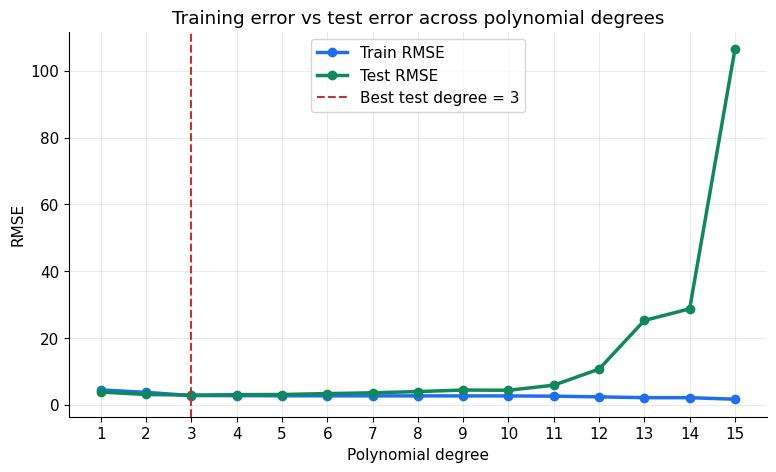

In [ ]:
best_degree_test = int(results.loc[results["test_RMSE"].idxmin(), "degree"]) # Find the degree corresponding to the minimum test RMSE from the 'results' DataFrame

plt.figure(figsize=(9, 5)) # Create a new figure for the plot with a specified size
plt.plot(results["degree"], results["train_RMSE"], marker="o", linewidth=2.5, label="Train RMSE", color="#1f6feb") # Plot training RMSE vs. degree with markers, line width, label, and color
plt.plot(results["degree"], results["test_RMSE"], marker="o", linewidth=2.5, label="Test RMSE", color="#11875d") # Plot test RMSE vs. degree with markers, line width, label, and color
plt.axvline(best_degree_test, color="#c3342f", linestyle="--", label=f"Best test degree = {best_degree_test}") # Add a vertical dashed line to indicate the best degree based on test RMSE
plt.title("Training error vs test error across polynomial degrees") # Set the title of the plot
plt.xlabel("Polynomial degree") # Set the x-axis label
plt.ylabel("RMSE") # Set the y-axis label
plt.xticks(results["degree"]) # Set x-axis ticks to be the specific degrees tested for clarity
plt.legend() # Display the legend to identify the plotted lines
plt.show() # Display the plot

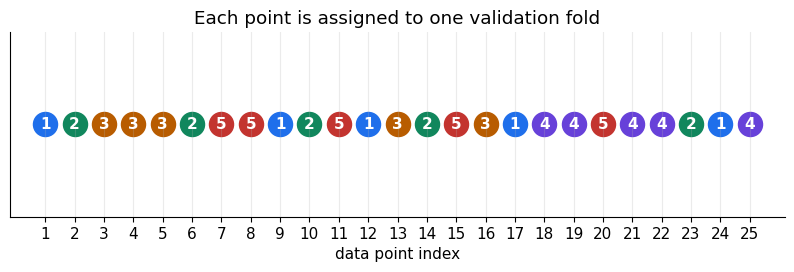

In [ ]:
n_points = 25 # Define the total number of data points to illustrate KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # Initialize KFold cross-validator with 5 splits, enabling shuffling, and using a fixed random state
fold_map = np.empty(n_points, dtype=int) # Create an empty NumPy array to store the fold assignment for each data point

for fold_id, (_, val_idx) in enumerate(kf.split(np.arange(n_points)), start=1): # Iterate through each fold generated by KFold (yielding train and validation indices)
    fold_map[val_idx] = fold_id # Assign the current 'fold_id' to the validation indices ('val_idx') for that fold

plt.figure(figsize=(10, 2.4)) # Create a figure for visualizing fold assignments with a specified size
colors = ["#1f6feb", "#11875d", "#b85c00", "#6741d9", "#c3342f"] # Define a list of distinct colors for different folds
for i, fold in enumerate(fold_map): # Iterate through each data point index 'i' and its assigned 'fold'
    plt.scatter(i, 1, s=300, color=colors[fold-1]) # Plot a colored circle for each data point at y=1, with color based on its fold assignment
    plt.text(i, 1, str(fold), color="white", ha="center", va="center", fontweight="bold") # Add the fold number as white text in the center of each circle
plt.yticks([]) # Remove y-axis ticks for a cleaner visualization
plt.xticks(range(n_points), range(1, n_points + 1)) # Set x-axis ticks to represent data point indices from 1 to 'n_points'
plt.title("Each point is assigned to one validation fold") # Set the title of the plot
plt.xlabel("data point index") # Set the x-axis label
plt.show() # Display the plot

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # Initialize KFold cross-validator for 5 splits, with shuffling and fixed random state
cv_rows = [] # Initialize an empty list to store cross-validation results for each degree

for degree in range(1, 16): # Iterate through polynomial degrees from 1 to 15 (inclusive)
    model = polynomial_model(degree) # Create a polynomial model pipeline for the current 'degree'
    scores = cross_validate( # Perform cross-validation using sklearn's `cross_validate` function
        model, # The model (pipeline) to evaluate
        X, # The features (input data)
        y, # The target variable (output data)
        cv=cv, # The cross-validation splitting strategy (KFold object)
        scoring="neg_root_mean_squared_error", # Metric to use: negative Root Mean Squared Error (negated because `cross_validate` maximizes scores)
        return_train_score=True, # Also return the scores calculated on the training sets of each fold
    )
    cv_rows.append({ # Append the cross-validation results to the 'cv_rows' list
        "degree": degree, # The current polynomial degree
        "train_RMSE_mean": -scores["train_score"].mean(), # Calculate the mean training RMSE (by negating the mean of 'train_score')
        "cv_RMSE_mean": -scores["test_score"].mean(), # Calculate the mean cross-validation (test) RMSE (by negating the mean of 'test_score')
        "cv_RMSE_std": scores["test_score"].std(), # Calculate the standard deviation of the cross-validation (test) RMSE
    })

cv_results = pd.DataFrame(cv_rows) # Convert the list of results into a Pandas DataFrame
cv_results # Display the cross-validation results DataFrame

,degree,train_RMSE_mean,cv_RMSE_mean,cv_RMSE_std
0,1,4.187440,4.269176,1.016103
1,2,3.455116,3.805618,0.782641
2,3,2.703375,3.072526,0.445353
3,4,2.680368,3.209064,0.456785
4,5,2.648191,3.162503,0.490289
5,6,2.604765,3.297932,0.413635
6,7,2.589674,3.445291,0.398783
7,8,2.562063,3.469547,0.396783
8,9,2.540871,3.610756,0.531378
9,10,2.513129,3.737127,0.446582


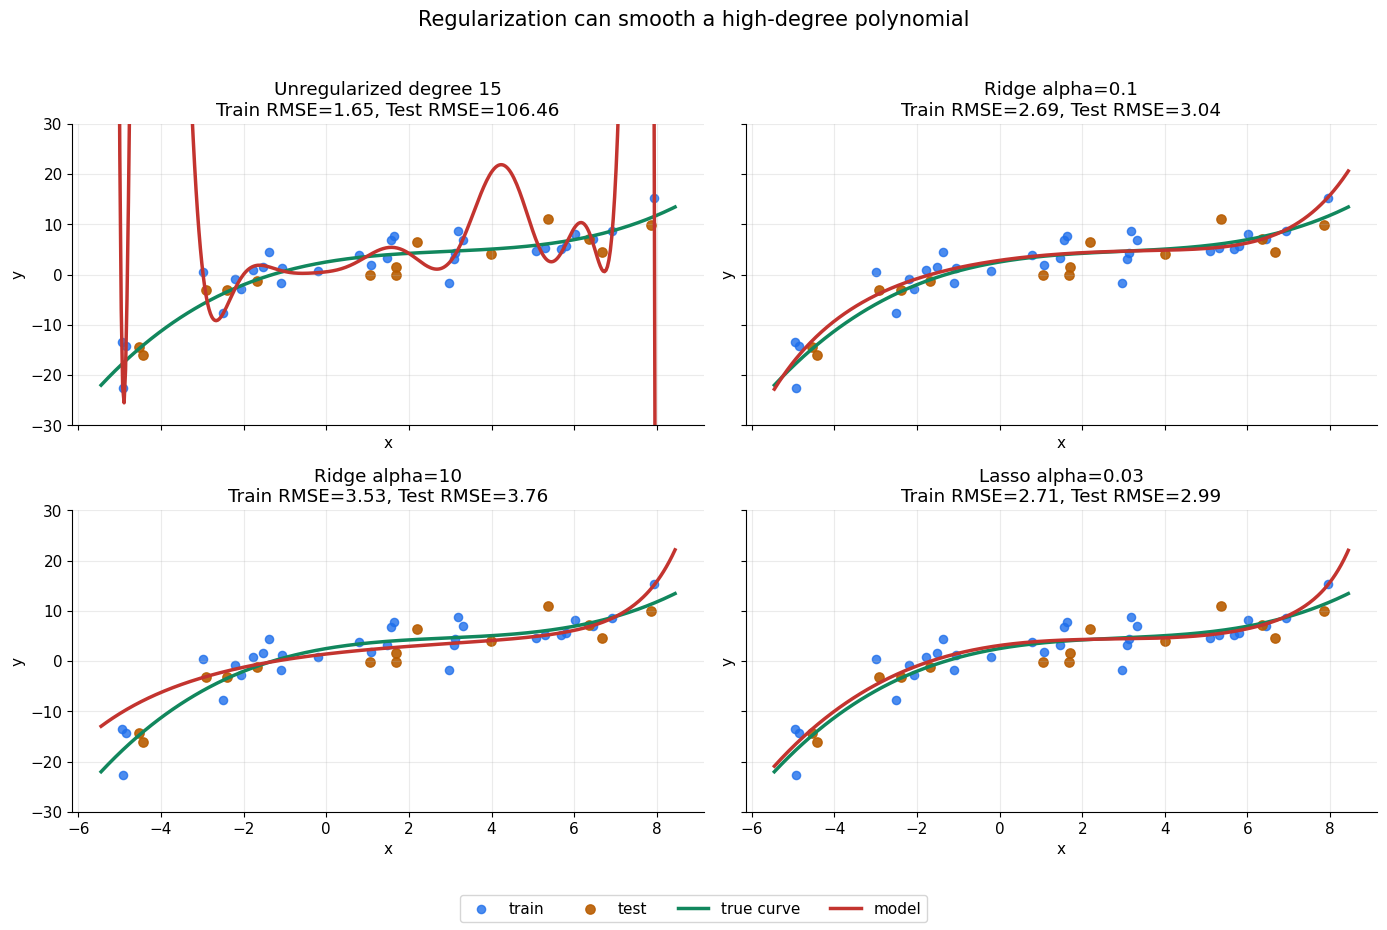

In [ ]:
high_degree = 15 # Define a high polynomial degree for demonstrating the effect of regularization
models = { # Define a dictionary of models to compare, including unregularized and regularized versions
    "Unregularized degree 15": polynomial_model(high_degree), # Unregularized model with a high polynomial degree
    "Ridge alpha=0.1": polynomial_model(high_degree, regularizer="ridge", alpha=0.1), # Ridge regression with a high degree and alpha=0.1
    "Ridge alpha=10": polynomial_model(high_degree, regularizer="ridge", alpha=10), # Ridge regression with a high degree and stronger regularization (alpha=10)
    "Lasso alpha=0.03": polynomial_model(high_degree, regularizer="lasso", alpha=0.03), # Lasso regression with a high degree and alpha=0.03
}
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True) # Create a 2x2 grid of subplots for comparison, sharing x and y axes
axes = axes.ravel() # Flatten the 2D array of axes into a 1D array for easier iteration

# Define a reasonable y-axis range for better visualization of regularized models, preventing extreme scales
y_min_limit = -30 # Set a minimum y-axis limit for all subplots
y_max_limit = 30 # Set a maximum y-axis limit for all subplots

for ax, (name, model) in zip(axes, models.items()): # Iterate through each subplot axis and corresponding model (name, pipeline object) from the 'models' dictionary
    model.fit(X_train, y_train) # Train the current model on the training data (X_train, y_train)
    pred_grid = model.predict(x_grid) # Predict y values for the dense x-grid to plot the model's curve
    train_error = rmse(y_train, model.predict(X_train)) # Calculate the Root Mean Squared Error on the training data
    test_error = rmse(y_test, model.predict(X_test)) # Calculate the Root Mean Squared Error on the test data

    ax.scatter(X_train[:, 0], y_train, color="#1f6feb", s=35, alpha=0.8, label="train") # Plot training data points as a scatter plot
    ax.scatter(X_test[:, 0], y_test, color="#b85c00", s=45, alpha=0.9, label="test") # Plot test data points as a scatter plot
    ax.plot(x_grid[:, 0], true_curve(x_grid[:, 0]), color="#11875d", linewidth=2.5, label="true curve") # Plot the true underlying curve
    ax.plot(x_grid[:, 0], pred_grid, color="#c3342f", linewidth=2.5, label="model") # Plot the model's prediction curve
    ax.set_title(f"{name}\nTrain RMSE={train_error:.2f}, Test RMSE={test_error:.2f}") # Set subplot title with model name, training RMSE, and test RMSE (formatted to 2 decimal places)
    ax.set_xlabel("x") # Set x-axis label for the current subplot
    ax.set_ylabel("y") # Set y-axis label for the current subplot
    ax.set_ylim(y_min_limit, y_max_limit) # Apply the consistent y-axis limits determined earlier

handles, labels = axes[0].get_legend_handles_labels() # Get legend handles and labels from the first subplot to create a common legend
fig.legend(handles, labels, loc="lower center", ncol=4) # Create a single legend for the entire figure at the bottom center with 4 columns
fig.suptitle("Regularization can smooth a high-degree polynomial", fontsize=15, y=1.02) # Set a main title for the entire figure, positioned slightly above the subplots
plt.tight_layout(rect=[0, 0.06, 1, 1]) # Adjust subplot parameters for a tight layout, leaving space for the legend and suptitle
plt.show() # Display the figure with all subplots

**SUMMARY:**

This notebook primarily demonstrates polynomial regression and the impact of feature engineering and regularization on model performance. Here's a summary of the key steps and concepts explored:

1.  **Data Generation**: Synthetic datasets are created to illustrate both simple quadratic relationships and more complex cubic relationships with added noise.
2.  **Polynomial Features**: The notebook explains and demonstrates how `PolynomialFeatures` transforms input features into higher-order polynomial terms and interaction terms, allowing linear models to fit non-linear data. It shows examples for both a single input feature and two input features, with and without `include_bias`.
3.  **Model Training and Evaluation (Simple Case)**: A basic linear regression model is trained on data transformed with polynomial features, showing how it can fit a non-linear curve.
4.  **Overfitting Demonstration**: By varying the polynomial degree, the notebook illustrates how increasing complexity (higher degrees) can lead to overfitting, where the model performs well on training data but poorly on unseen test data, indicated by a divergence between training and testing RMSE.
5.  **Cross-Validation**: The concept of K-Fold cross-validation is introduced and visualized to explain how models are evaluated more robustly on different subsets of data.
6.  **Regularization**: The notebook showcases how regularization techniques (Ridge and Lasso) can mitigate overfitting in high-degree polynomial models, leading to smoother and more generalizable curves by penalizing large coefficients. This helps in finding a better balance between bias and variance.

In essence, the notebook walks through the process of building more flexible regression models using polynomial features and how to manage the trade-off between model complexity and generalization using techniques like cross-validation and regularization.

# ***More explanation on polynomialfeatures object from scikitlearn***

### Deeper Dive into `PolynomialFeatures`

When `PolynomialFeatures` is applied to a single input feature, let's say `x`, with `include_bias=True` (which is the default behavior), it generates new features based on the powers of `x` up to the specified degree.

For an input feature `x`:

*   **`degree=1`**: The output features would be `[1, x]`. The `1` represents the intercept (bias) term, and `x` is the original feature.

*   **`degree=2`**: The output features would be `[1, x, x^2]`. This adds the squared term of `x`.

*   **`degree=3`**: The output features would be `[1, x, x^2, x^3]`. It adds the cubic term of `x`.

*   **`degree=4`**: The output features would be `[1, x, x^2, x^3, x^4]`. It adds the quartic term of `x`.

Each column in the transformed output `X_poly` corresponds to one of these generated features. This allows a linear model to capture non-linear relationships by effectively fitting a polynomial curve to the data.

In [ ]:
# Let's demonstrate with a single input feature and different degrees

single_feature_input = np.array([[2]]) # Our single input feature is 2

print(f"Original single input feature: {single_feature_input.flatten()[0]}\n")

# --- Degree 3 ---
poly_degree_3 = PolynomialFeatures(degree=3, include_bias=True) # include_bias is default, but explicit for clarity
transformed_features_3 = poly_degree_3.fit_transform(single_feature_input)
print("PolynomialFeatures with degree=3:")
print(f"  Features generated: {poly_degree_3.get_feature_names_out(['x'])}")
print(f"  Transformed output: {transformed_features_3}\n")

# --- Degree 4 ---
poly_degree_4 = PolynomialFeatures(degree=4, include_bias=True)
transformed_features_4 = poly_degree_4.fit_transform(single_feature_input)
print("PolynomialFeatures with degree=4:")
print(f"  Features generated: {poly_degree_4.get_feature_names_out(['x'])}")
print(f"  Transformed output: {transformed_features_4}")


### `PolynomialFeatures` with Two Input Parameters (and `include_bias=False`)

When you have two input features, let's call them `x1` and `x2`, `PolynomialFeatures` generates new features by considering powers of each feature and their products (interaction terms) up to the specified degree. With `include_bias=False`, the constant term (1) is *not* included.

Let's break it down by degree for inputs `x1` and `x2`:

*   **`degree=1`**: Generates `[x1, x2]`. These are just the original features.

*   **`degree=2`**: Generates `[x1, x2, x1^2, x1*x2, x2^2]`.
    *   `x1`, `x2`: Original features (from degree 1).
    *   `x1^2`, `x2^2`: Squared terms of individual features.
    *   `x1*x2`: The interaction term between `x1` and `x2`.

*   **`degree=3`**: Generates `[x1, x2, x1^2, x1*x2, x2^2, x1^3, x1^2*x2, x1*x2^2, x2^3]`.
    *   Includes all terms from `degree=2`.
    *   `x1^3`, `x2^3`: Cubic terms of individual features.
    *   `x1^2*x2`, `x1*x2^2`: Higher-order interaction terms where the sum of powers is 3 (e.g., $x_1^2 x_2^1$, $x_1^1 x_2^2$).

*   **`degree=4`**: Generates `[x1, x2, x1^2, x1*x2, x2^2, x1^3, x1^2*x2, x1*x2^2, x2^3, x1^4, x1^3*x2, x1^2*x2^2, x1*x2^3, x2^4]`.
    *   Includes all terms from `degree=3`.
    *   `x1^4`, `x2^4`: Quartic terms of individual features.
    *   `x1^3*x2`, `x1^2*x2^2`, `x1*x2^3`: Higher-order interaction terms where the sum of powers is 4 (e.g., $x_1^3 x_2^1$, $x_1^2 x_2^2$, $x_1^1 x_2^3$).

This expansion allows a linear model to capture complex, non-linear relationships by creating a feature space that includes interactions and higher powers of the original features.

In [ ]:
# Let's demonstrate with two input features: x1 = 2, x2 = 3

two_feature_input = np.array([[2, 3]])

print(f"Original two input features: {two_feature_input.flatten()}\n")

# --- Degree 1 (Linear) ---
poly_degree_1_two_features = PolynomialFeatures(degree=1, include_bias=False)
transformed_features_1_two_features = poly_degree_1_two_features.fit_transform(two_feature_input)
print("PolynomialFeatures with degree=1 (include_bias=False):")
print(f"  Features generated: {poly_degree_1_two_features.get_feature_names_out(['x1', 'x2'])}")
print(f"  Transformed output: {transformed_features_1_two_features}\n")

# --- Degree 2 (Quadratic) ---
poly_degree_2_two_features = PolynomialFeatures(degree=2, include_bias=False)
transformed_features_2_two_features = poly_degree_2_two_features.fit_transform(two_feature_input)
print("PolynomialFeatures with degree=2 (include_bias=False):")
print(f"  Features generated: {poly_degree_2_two_features.get_feature_names_out(['x1', 'x2'])}")
print(f"  Transformed output: {transformed_features_2_two_features}\n")

# --- Degree 3 (Cubic) ---
poly_degree_3_two_features = PolynomialFeatures(degree=3, include_bias=False)
transformed_features_3_two_features = poly_degree_3_two_features.fit_transform(two_feature_input)
print("PolynomialFeatures with degree=3 (include_bias=False):")
print(f"  Features generated: {poly_degree_3_two_features.get_feature_names_out(['x1', 'x2'])}")
print(f"  Transformed output: {transformed_features_3_two_features}\n")

# --- Degree 4 (Quartic) ---
poly_degree_4_two_features = PolynomialFeatures(degree=4, include_bias=False)
transformed_features_4_two_features = poly_degree_4_two_features.fit_transform(two_feature_input)
print("PolynomialFeatures with degree=4 (include_bias=False):")
print(f"  Features generated: {poly_degree_4_two_features.get_feature_names_out(['x1', 'x2'])}")
print(f"  Transformed output: {transformed_features_4_two_features}")
